In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/weekly_sales_by_category.csv", parse_dates=["week_start"])

print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print(df["category_group"].value_counts())
print()
print(df.groupby("category_group")["week_start"].agg(["min", "max"]))

Shape: (2922, 4)

week_start             datetime64[ns]
category_group                 object
total_sales_dollars           float64
total_bottles_sold              int64
dtype: object

category_group
100% AGAVE TEQUILA           487
ALL_OTHER                    487
AMERICAN VODKAS              487
CANADIAN WHISKIES            487
STRAIGHT BOURBON WHISKIES    487
WHISKEY LIQUEUR              487
Name: count, dtype: int64

                                 min        max
category_group                                 
100% AGAVE TEQUILA        2017-01-02 2026-04-27
ALL_OTHER                 2017-01-02 2026-04-27
AMERICAN VODKAS           2017-01-02 2026-04-27
CANADIAN WHISKIES         2017-01-02 2026-04-27
STRAIGHT BOURBON WHISKIES 2017-01-02 2026-04-27
WHISKEY LIQUEUR           2017-01-02 2026-04-27


(487, 2)
  week_start  total_sales
0 2017-01-02   3844692.44
1 2017-01-09   4841547.61
2 2017-01-16   4519706.03
3 2017-01-23   4763505.57
4 2017-01-30   5120235.60
    week_start  total_sales
482 2026-03-30   7946242.12
483 2026-04-06   8124914.21
484 2026-04-13   7300776.30
485 2026-04-20   7387463.93
486 2026-04-27   6406210.04


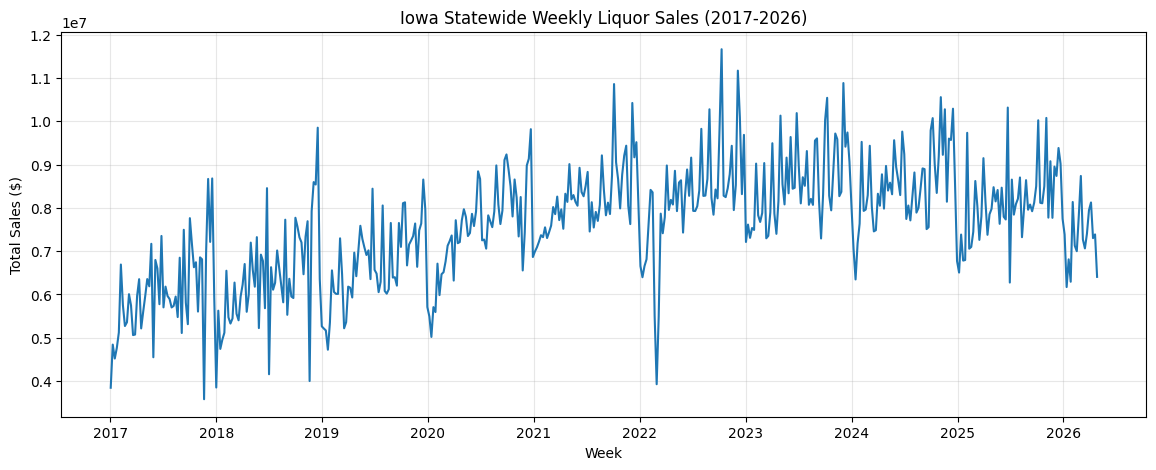

In [3]:
statewide = df.groupby("week_start")["total_sales_dollars"].sum().reset_index()
statewide.columns = ["week_start", "total_sales"]

print(statewide.shape)
print(statewide.head())
print(statewide.tail())

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.plot(statewide["week_start"], statewide["total_sales"])
plt.title("Iowa Statewide Weekly Liquor Sales (2017-2026)")
plt.xlabel("Week")
plt.ylabel("Total Sales ($)")
plt.grid(alpha=0.3)
plt.show()

In [4]:
statewide["year"] = statewide["week_start"].dt.year
statewide["month"] = statewide["week_start"].dt.month

print("Yearly total sales (trend check):")
print(statewide.groupby("year")["total_sales"].sum().round(0))
print()

print("Average sales by month, across all years (seasonality check):")
print(statewide.groupby("month")["total_sales"].mean().round(0))
print()

print("Single biggest week (potential anomaly):")
print(statewide.loc[statewide["total_sales"].idxmax()])
print()
print("Single smallest week (potential anomaly):")
print(statewide.loc[statewide["total_sales"].idxmin()])

Yearly total sales (trend check):
year
2017    313768135.0
2018    337352014.0
2019    348221771.0
2020    393522231.0
2021    428130592.0
2022    428957928.0
2023    446641666.0
2024    451448863.0
2025    423637762.0
2026    124390468.0
Name: total_sales, dtype: float64

Average sales by month, across all years (seasonality check):
month
1     6221371.0
2     6988883.0
3     7170623.0
4     7373916.0
5     7748497.0
6     8042478.0
7     7419036.0
8     7765786.0
9     7615859.0
10    8356432.0
11    8012895.0
12    8640065.0
Name: total_sales, dtype: float64

Single biggest week (potential anomaly):
week_start     2022-10-10 00:00:00
total_sales            11665917.37
year                          2022
month                           10
Name: 301, dtype: object

Single smallest week (potential anomaly):
week_start     2017-11-20 00:00:00
total_sales             3579289.61
year                          2017
month                           11
Name: 46, dtype: object


In [5]:
spike_week = df[df["week_start"] == "2022-10-10"]
print(spike_week)
print()

# Compare to the same week in surrounding years to see if this is a recurring Oct pattern or a one-off
oct_second_week = statewide[(statewide["month"] == 10) & (statewide["week_start"].dt.day <= 14) & (statewide["week_start"].dt.day >= 8)]
print(oct_second_week[["week_start", "total_sales"]])

     week_start             category_group  total_sales_dollars  \
1806 2022-10-10         100% AGAVE TEQUILA            800186.37   
1807 2022-10-10                  ALL_OTHER           5879032.05   
1808 2022-10-10            AMERICAN VODKAS           2037932.10   
1809 2022-10-10          CANADIAN WHISKIES           1104881.54   
1810 2022-10-10  STRAIGHT BOURBON WHISKIES           1136152.24   
1811 2022-10-10            WHISKEY LIQUEUR            707733.07   

      total_bottles_sold  
1806               27141  
1807              353712  
1808              161876  
1809               65862  
1810               48783  
1811               91478  

    week_start  total_sales
40  2017-10-09   7173484.77
92  2018-10-08   7568322.14
145 2019-10-14   8128098.00
197 2020-10-12   8501609.08
249 2021-10-11   9052343.40
301 2022-10-10  11665917.37
353 2023-10-09  10543151.19
406 2024-10-14   9006420.20
458 2025-10-13   8117640.39


## Summary

This notebook explores 9 plus years of Iowa liquor sales data (34 million raw transactions, aggregated to weekly totals via BigQuery), validating data quality and understanding trend and seasonality before any modeling.

Data quality decisions:

1. Restricted to 2017 onward after discovering a category taxonomy change (71 to 96 categories before 2017 versus a stable 44 to 48 after 2017)
2. Excluded returns and corrections (0.032 percent of rows, sale_dollars less than 0)
3. Excluded rows with null category_name
4. Confirmed zero gaps in the resulting weekly series (487 of 487 weeks present, January 2 2017 to April 27 2026)

Key findings:

1. Strong growth 2017 to 2024 (approximately 314 million dollars to 451 million dollars, about a 44 percent increase), but 2025 saw the first year over year decline (approximately 424 million dollars). A model should not assume growth continues indefinitely.
2. Moderate seasonality: December highest (approximately 8.64 million dollars weekly average), January lowest (approximately 6.22 million dollars), about a 39 percent swing.
3. The second week of October is reliably one of the strongest weeks every single year from 2017 to 2025, broad based across categories. Confirmed as a real recurring pattern after investigating the single highest week in the dataset (October 2022, 11.67 million dollars), not an anomaly.

Next steps: build a naive and seasonal baseline, then compare SARIMA, Prophet, and an ML based approach, evaluated on a proper time based holdout with MAPE and RMSE.